<a href="https://colab.research.google.com/github/bouallalhouda/Blog-Posts/blob/main/PREDICTION_FLOOD.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Importationlibraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Downalding Excel dataset
df = pd.read_excel("/flood echanti.xlsx")

#  5 first rows
print("Aperçu des données :")
print(df.head())

# Informations sur les colonnes et leurs types
print("\nInformations sur les données :")
print(df.info())

# Statistiques descriptives
print("\nStatistiques descriptives :")
print(df.describe())

Aperçu des données :
   ID  MonsoonIntensity  TopographyDrainage  RiverManagement  Deforestation  \
0   1               3.0                 8.0              6.0            6.0   
1   2               8.0                 4.0              5.0            7.0   
2   3               3.0                10.0              4.0            1.0   
3   4               4.0                 4.0              2.0            7.0   
4   5               3.0                 7.0              5.0            2.0   

   Urbanization  ClimateChange  DamsQuality  Siltation  AgriculturalPractices  \
0           4.0            4.0          6.0        2.0                    3.0   
1           7.0            9.0          1.0        5.0                    5.0   
2           7.0            5.0          4.0        7.0                    4.0   
3           3.0            4.0          1.0        4.0                    6.0   
4           5.0            8.0          5.0        2.0                    7.0   

   ...  CoastalVu

In [18]:
# Disponible variables
print("Colonnes disponibles :")
for i, col in enumerate(df.columns):
    print(f"{i:2d}. {col}")

# Target
y = df['FloodProbability']
print(f"\nVariable cible (Y) : FloodProbability")

# variables explicatives (X)
X = df.drop(columns=['ID', 'FloodProbability', 'filter_$'])
print(f"Variables explicatives (X) : {len(X.columns)} variables")
print(X.columns.tolist())

Colonnes disponibles :
 0. ID
 1. MonsoonIntensity
 2. TopographyDrainage
 3. RiverManagement
 4. Deforestation
 5. Urbanization
 6. ClimateChange
 7. DamsQuality
 8. Siltation
 9. AgriculturalPractices
10. Encroachments
11. IneffectiveDisasterPreparedness
12. DrainageSystems
13. CoastalVulnerability
14. Landslides
15. Watersheds
16. DeterioratingInfrastructure
17. PopulationScore
18. WetlandLoss
19. InadequatePlanning
20. PoliticalFactors
21. FloodProbability
22. filter_$

Variable cible (Y) : FloodProbability
Variables explicatives (X) : 20 variables
['MonsoonIntensity', 'TopographyDrainage', 'RiverManagement', 'Deforestation', 'Urbanization', 'ClimateChange', 'DamsQuality', 'Siltation', 'AgriculturalPractices', 'Encroachments', 'IneffectiveDisasterPreparedness', 'DrainageSystems', 'CoastalVulnerability', 'Landslides', 'Watersheds', 'DeterioratingInfrastructure', 'PopulationScore', 'WetlandLoss', 'InadequatePlanning', 'PoliticalFactors']


In [19]:
# Vérification du nombre de valeurs manquantes
missing_values = df.isnull().sum()
missing_percent = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Variable': missing_values.index,
    'Valeurs manquantes': missing_values.values,
    'Pourcentage (%)': missing_percent.values
})
missing_df = missing_df[missing_df['Valeurs manquantes'] > 0]
print("Variables avec valeurs manquantes :")
print(missing_df)

Variables avec valeurs manquantes :
                           Variable  Valeurs manquantes  Pourcentage (%)
1                  MonsoonIntensity                 313          0.62595
2                TopographyDrainage                 312          0.62395
3                   RiverManagement                 312          0.62395
4                     Deforestation                 312          0.62395
5                      Urbanization                 312          0.62395
6                     ClimateChange                 312          0.62395
7                       DamsQuality                 312          0.62395
8                         Siltation                 312          0.62395
9             AgriculturalPractices                 312          0.62395
10                    Encroachments                 312          0.62395
11  IneffectiveDisasterPreparedness                 312          0.62395
12                  DrainageSystems                 312          0.62395
13             

In [20]:
# Suppression des lignes avec valeurs manquantes
df_clean = df.dropna()
print(f"Taille après suppression : {df_clean.shape}")

# Mise à jour des variables
y = df_clean['FloodProbability']
X = df_clean.drop(columns=['ID', 'FloodProbability', 'filter_$'])
print(f"Observations utilisées : {len(y)}")

Taille après suppression : (49691, 23)
Observations utilisées : 49691


In [21]:
import statsmodels.api as sm

# 2. Ensuite ajouter la constante et construire le modèle
X_avec_constante = sm.add_constant(X)
modele = sm.OLS(y, X_avec_constante).fit()

print(modele.summary())

                            OLS Regression Results                            
Dep. Variable:       FloodProbability   R-squared:                       1.000
Model:                            OLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.437e+31
Date:                Fri, 13 Mar 2026   Prob (F-statistic):               0.00
Time:                        14:38:44   Log-Likelihood:             1.6666e+06
No. Observations:               49691   AIC:                        -3.333e+06
Df Residuals:                   49670   BIC:                        -3.333e+06
Df Model:                          20                                         
Covariance Type:            nonrobust                                         
                                      coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const     

In [22]:
# Extraction des coefficients
coefficients = modele.params

# Affichage de l'équation complète
print("Équation du modèle :")
print(f"FloodProbability = {coefficients['const']:.4f}", end="")

for var in X.columns:
    print(f" + {coefficients[var]:.4f} × {var}", end="")

# Version simplifiée avec les variables significatives seulement
print("\n\n--- Variables significatives (p < 0.05) ---")
significatifs = modele.pvalues[modele.pvalues < 0.05].index
print(f"FloodProbability = {coefficients['const']:.4f}", end="")
for var in significatifs:
    if var != 'const':
        print(f" + {coefficients[var]:.4f} × {var}", end="")

Équation du modèle :
FloodProbability = -0.0000 + 0.0050 × MonsoonIntensity + 0.0050 × TopographyDrainage + 0.0050 × RiverManagement + 0.0050 × Deforestation + 0.0050 × Urbanization + 0.0050 × ClimateChange + 0.0050 × DamsQuality + 0.0050 × Siltation + 0.0050 × AgriculturalPractices + 0.0050 × Encroachments + 0.0050 × IneffectiveDisasterPreparedness + 0.0050 × DrainageSystems + 0.0050 × CoastalVulnerability + 0.0050 × Landslides + 0.0050 × Watersheds + 0.0050 × DeterioratingInfrastructure + 0.0050 × PopulationScore + 0.0050 × WetlandLoss + 0.0050 × InadequatePlanning + 0.0050 × PoliticalFactors

--- Variables significatives (p < 0.05) ---
FloodProbability = -0.0000 + 0.0050 × MonsoonIntensity + 0.0050 × TopographyDrainage + 0.0050 × RiverManagement + 0.0050 × Deforestation + 0.0050 × Urbanization + 0.0050 × ClimateChange + 0.0050 × DamsQuality + 0.0050 × Siltation + 0.0050 × AgriculturalPractices + 0.0050 × Encroachments + 0.0050 × IneffectiveDisasterPreparedness + 0.0050 × DrainageSys

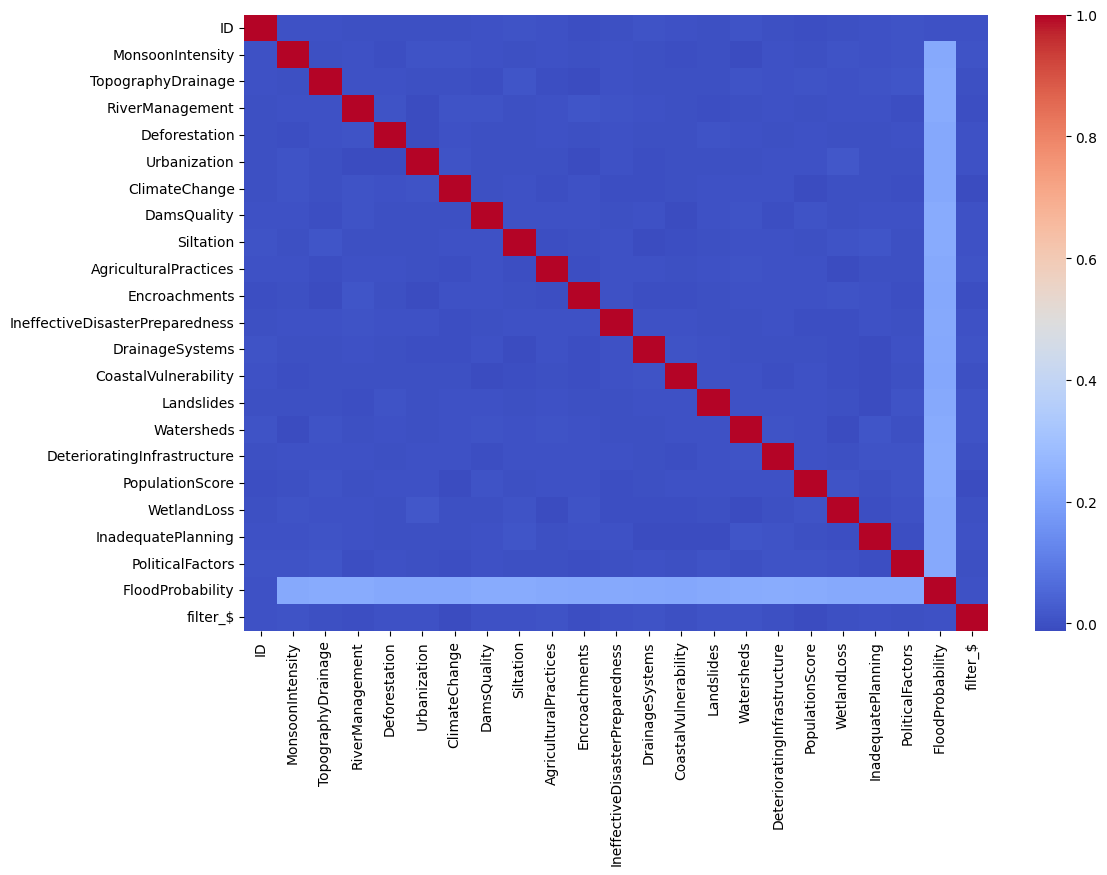

In [23]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [25]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("R2 score:", r2_score(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))

R2 score: 0.7313613749460608
MSE: 0.0006861543395336539


In [27]:
y = (df["FloodProbability"] > df["FloodProbability"].median()).astype(int)
X = df.drop("FloodProbability", axis=1)

In [28]:
accuracy = r2_score(y_test, y_pred) * 100
print("Approximate accuracy:", accuracy, "%")

Approximate accuracy: 73.13613749460607 %


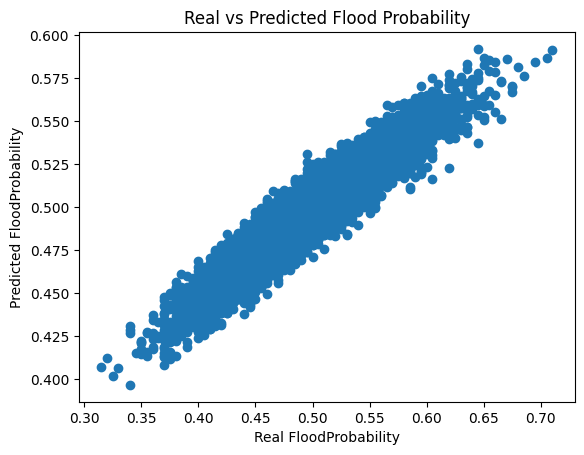

In [29]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Real FloodProbability")
plt.ylabel("Predicted FloodProbability")
plt.title("Real vs Predicted Flood Probability")
plt.show()

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

In [35]:
# Création du modèle Lasso
# alpha est le paramètre de régularisation (plus alpha est grand, plus la régularisation est forte)
lasso_model = Lasso(alpha=0.1, max_iter=10000, random_state=42)

# Entraînement du modèle
lasso_model.fit(X_train_scaled, y_train)

Lasso(alpha=0.1, max_iter=10000, random_state=42)

In [40]:

from sklearn.linear_model import Lasso

# Réduire significativement alpha pour permettre des coefficients non-nuls
lasso_model = Lasso(alpha=0.001, max_iter=10000, random_state=42)
lasso_model.fit(X_train_scaled, y_train)

# Prédictions
y_train_pred = lasso_model.predict(X_train_scaled)
y_test_pred = lasso_model.predict(X_test_scaled)

# Évaluation des performances
train_mse = mean_squared_error(y_train, y_train_pred)
test_mse = mean_squared_error(y_test, y_test_pred)
train_r2 = r2_score(y_train, y_train_pred)
test_r2 = r2_score(y_test, y_test_pred)

print("Résultats du modèle Lasso :")
print(f"Coefficients : {lasso_model.coef_}")
print(f"Nombre de coefficients non-nuls : {np.sum(lasso_model.coef_ != 0)}")
print(f"Intercept : {lasso_model.intercept_}")
print(f"\nPerformance sur l'ensemble d'entraînement :")
print(f"MSE : {train_mse:.4f}")
print(f"R² : {train_r2:.4f}")
print(f"\nPerformance sur l'ensemble de test :")
print(f"MSE : {test_mse:.4f}")
print(f"R² : {test_r2:.4f}")

Résultats du modèle Lasso :
Coefficients : [0.0881874  0.08976139 0.08634242 0.08847505 0.08653664 0.08795483
 0.08891493 0.08741242 0.08791109 0.08672154 0.08992188 0.0887411
 0.0905359  0.08733813 0.09107973 0.08934528 0.08861799 0.08547211
 0.08654575 0.08768532]
Nombre de coefficients non-nuls : 20
Intercept : 0.4696367478365868

Performance sur l'ensemble d'entraînement :
MSE : 0.0903
R² : 0.6376

Performance sur l'ensemble de test :
MSE : 0.0902
R² : 0.6378
